In [ ]:
USER = "varom"

import ROOT
import pandas as pd
import numpy as np

path_root = '/data/at3/common/EWK2L3L_ANA-SUSY-2024-02/FFntuples/RUN2_v2'

#SUSY MC signal ---------------------------------------------------------------------------

#file_C1N2_WZ_2L = f"{path_root}/SIGNAL/C1N2_WZ_2L_569622_mc20a_fastsim.root"
file_C1N2_WZ_2L = f'{path_root}/C1N2_WZ_2L_569238_mc20e_fastsim.root'

#SM MC background --------------------------------------------------------------------------

#file_VVV = f'{path_root}/VVV_701235_mc20a_fullsim.root'
file_VVV = f"{path_root}/VVV_701235_mc20e_fullsim.root"

#file_VV = f'{path_root}/VV_Sh2212_700600_mc20a_fullsim.root'
file_VV = f'{path_root}/VV_Sh2212_700600_mc20e_fullsim.root'

file_Vy = f'{path_root}/Vy_Sh2214_700770_mc20e_fullsim.root'

file_Wjets_lv = f'{path_root}/Wjets_lv_700338_mc20e_fullsim.root'

#file_Zjets_ll = f'{path_root}/Zjets_ll_700320_mc20a_fullsim.root'
file_Zjets_ll = f'{path_root}/Zjets_ll_700320_mc20e_fullsim.root'

file_Zjets_lowMLL = f'{path_root}/Zjets_lowMLL_700467_mc20e_fullsim.root'

file_higgs = f'{path_root}/higgs_345097_mc20e_fullsim.root'

file_othertop = f'{path_root}/othertop_304014_mc20e_fullsim.root'

file_ttbar_allhad = f'{path_root}/ttbar_allhad_410471_mc20e_fullsim.root'

file_ttbar_dil = f'{path_root}/ttbar_dil_410472_mc20e_fullsim.root'

file_ttbar_nonallhad = f'{path_root}/ttbar_nonallhad_410470_mc20e_fullsim.root'


In [2]:
import uproot
import awkward as ak

# ROOT TO PANDAS BUT USING UPROOT (FLATTENS THE DATA IN CASE THERE ARE MULTIPLE CANDIDATES)

def convert_ROOT_to_pd(filename,cols):
    #Convierte un ROOT file a un DataFrame de pandas de manera segura,incluso si contiene columnas vectoriales.
    
    with uproot.open(filename) as f:
        tree = f["analysis"]

        if cols == None:
            all_columns = tree.keys()
        else:
            all_columns = cols

        arr = tree.arrays(all_columns, library="ak")
        df = ak.to_dataframe(arr).copy()
    return df


In [3]:
columns = ['L2_RJ_R_ISR_NOSYS','L2_mt2_NOSYS','L2_mt2100_NOSYS','met_GeV_NOSYS','jet_n_NOSYS',
    #'ljet_n_NOSYS','bjet_n_NOSYS',
    'L2_dR_ll_NOSYS', 'L2_dPhi_ll_NOSYS', 'L2_dPhi_METj_NOSYS', 'L2_ptll_NOSYS','weight_total_NOSYS','L2_mll_NOSYS','L2_mSFOS_NOSYS',
    'L2_RJ_ISR_pt_NOSYS','L2_RJ_MTS_NOSYS']

In [4]:
df_C1N2_WZ_2L = convert_ROOT_to_pd(file_C1N2_WZ_2L,columns)
df_VV = convert_ROOT_to_pd(file_VV,columns)
#df_ttbar_nonallhad = convert_ROOT_to_pd(file_ttbar_nonallhad,columns)
#df_ttbar_dil = convert_ROOT_to_pd(file_ttbar_dil,columns)
#df_ttbar_allhad = convert_ROOT_to_pd(file_ttbar_allhad,columns)

In [5]:
def search_samecols(df1, df2):
    """
    Devuelve las columnas comunes entre dos DataFrames
    y el número de columnas comunes.
    """
    same_cols = list(df1.columns.intersection(df2.columns))
    cols_df1 = df1.shape[1]
    cols_df2 = df2.shape[1]
    n_same = len(same_cols)

    print(
        f"There are {n_same} shared columns."
        f"df1 and df2 have {cols_df1} and {cols_df2} columns, respectively."
    )

In [6]:
search_samecols(df_C1N2_WZ_2L,df_VV)

There are 14 shared columns.df1 and df2 have 14 and 14 columns, respectively.


# 1 for SUSY signal, 0 for SM background

In [7]:
df_C1N2_WZ_2L['BKGCAT_BIN'] = 1
df_VV['BKGCAT_BIN'] = 0

df = pd.concat([df_C1N2_WZ_2L, df_VV], ignore_index=True)

In [8]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import os 
import seaborn as sns
import pandas as pd
import numpy as np

# -------------------------------- PLOT HISTOGRAM ----------------------------------------------------------------------

def plot_hist(df, column_name, title, x_min, x_max, ax, lin_log, epsilon,use_latex, wbins_dict=None, units_dict=None):

    # df: dataframe
    # column_name: name of the variable that we want to plot
    # title: title
    # x_min: minimum plotting range
    # x_max: maximum plotting range
    # ax
    # lin_log: linear or logarithmic plotting, ie log(data), not logarithmic axis
    # epsilon: very small value that avoids divergences on the plotting
    # wbins_dict: bin width
    # units_dict: units of the variable
    # use_latex: True for latex, false for non-latex
    
    if column_name not in df.columns:
        print(f"La columna '{column_name}' no existe en el DataFrame.")
        return

    bin_width = wbins_dict[column_name] if (wbins_dict and column_name in wbins_dict) else 0.1
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)

    groups = [
            ((df.BKGCAT_BIN==0), "SM VV bkg", "skyblue"),
            ((df.BKGCAT_BIN==1), "BSM 2L signal", "salmon"),
        ]

    for mask, label, color in groups:
        data = df.loc[mask, column_name]
        if len(data) == 0:
            continue
        if lin_log == 'log':
            data = data[data >= 0].copy()
            data = data.replace(0, epsilon)   # sustituir únicamente los ceros
            data = np.log10(data)
            
        ax.hist(data, bins=bin_edges, histtype="stepfilled", alpha=0.5, density=True, edgecolor=color,
                linewidth=3, label=label, color=color)

    ax.set_xlim(x_min, x_max)

    # --- Units ---
    units = units_dict.get(column_name) if units_dict else None
    bw_str = str(int(bin_width)) if bin_width == int(bin_width) else f"{bin_width:g}"

    # X label
    if use_latex == True:
        x_base = column_name.replace('_', r'\_')
    else:
        x_base = column_name
        
    x_label = rf"{x_base} $[{units}]$" if units else x_base

    # Y label
    y_label = rf"Norm. events / ${bw_str}\;{units}$" if units else rf"Norm. events / ${bw_str}$"

    ax.set_xlabel(x_label, loc="center")
    ax.set_ylabel(y_label, loc="top")
    ax.legend(fontsize=18, frameon=True)

# ------------ PLOT MULTIPLE HISTOGRAMS AT ONCE -----------------------------------------------------------------------

def subplot_hist(df, variables, title, x_ranges, lin_log_dict, epsilon, use_latex,wbins_dict=None, units_dict=None):
    
    # df: dataframe
    # variables: dictionary with the variables that we want to plot
    # title: title
    # x_ranges: dictionary of plotting ranges
    # lin_log: dictionary that indicates linear or logarithmic plotting, ie log(data), not logarithmic axis
    # epsilon: very small value that avoids divergences on the plotting
    # wbins_dict: bin width
    # units_dict: units of the variable
    # use_latex: True for latex, false for non-latex
    
    N = len(variables)
    ncols = 3
    nrows = (N + ncols - 1) // ncols

    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "mathtext.fontset": "dejavuserif",
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "figure.figsize": (8, 20),
        "figure.dpi": 150,
        "text.usetex": use_latex #Cambiar a true si me apetece
    })

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    fig.suptitle(title, fontsize=24)
    axes = axes.flatten()

    for ax, var in zip(axes, variables):
        if var not in x_ranges:
            print(f"Rango no definido para {var}, se salta")
            continue
        lin_log = lin_log_dict.get(var, 'lin') # Searches inside the lin_log dictionary. If 'None', fill with 'lin'
        x_min, x_max = x_ranges[var]
        plot_hist(df=df, column_name=var, title=title, x_min=x_min, x_max=x_max,
                     ax=ax, lin_log=lin_log, epsilon=epsilon, use_latex=use_latex,wbins_dict=wbins_dict, units_dict=units_dict)

    for ax in axes[N:]:
        ax.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    return fig, axes

# ------------------------- FUNCTION TO SAVE PLOTS -------------------------------------

import os

def save_plot(USER, directory, fig, pdfname):

    # USER
    # directory: directory into which the pdf file is going
    # fig: figure
    # pdfname
    
    if USER != "varom":
        return

    os.makedirs(directory, exist_ok=True)

    filename = os.path.join(directory, f"{pdfname}.pdf")
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close(fig)

    

In [9]:
for col in df_C1N2_WZ_2L.columns:
    print(col)

L2_RJ_R_ISR_NOSYS
L2_mt2_NOSYS
L2_mt2100_NOSYS
met_GeV_NOSYS
jet_n_NOSYS
L2_dR_ll_NOSYS
L2_dPhi_ll_NOSYS
L2_dPhi_METj_NOSYS
L2_ptll_NOSYS
weight_total_NOSYS
L2_mll_NOSYS
L2_mSFOS_NOSYS
L2_RJ_ISR_pt_NOSYS
L2_RJ_MTS_NOSYS
BKGCAT_BIN


In [10]:
def search_cols(df,word):
    pid_columns = [col for col in df.columns if word in col]

    return pid_columns

search_cols(df,'weight_total')

['weight_total_NOSYS']

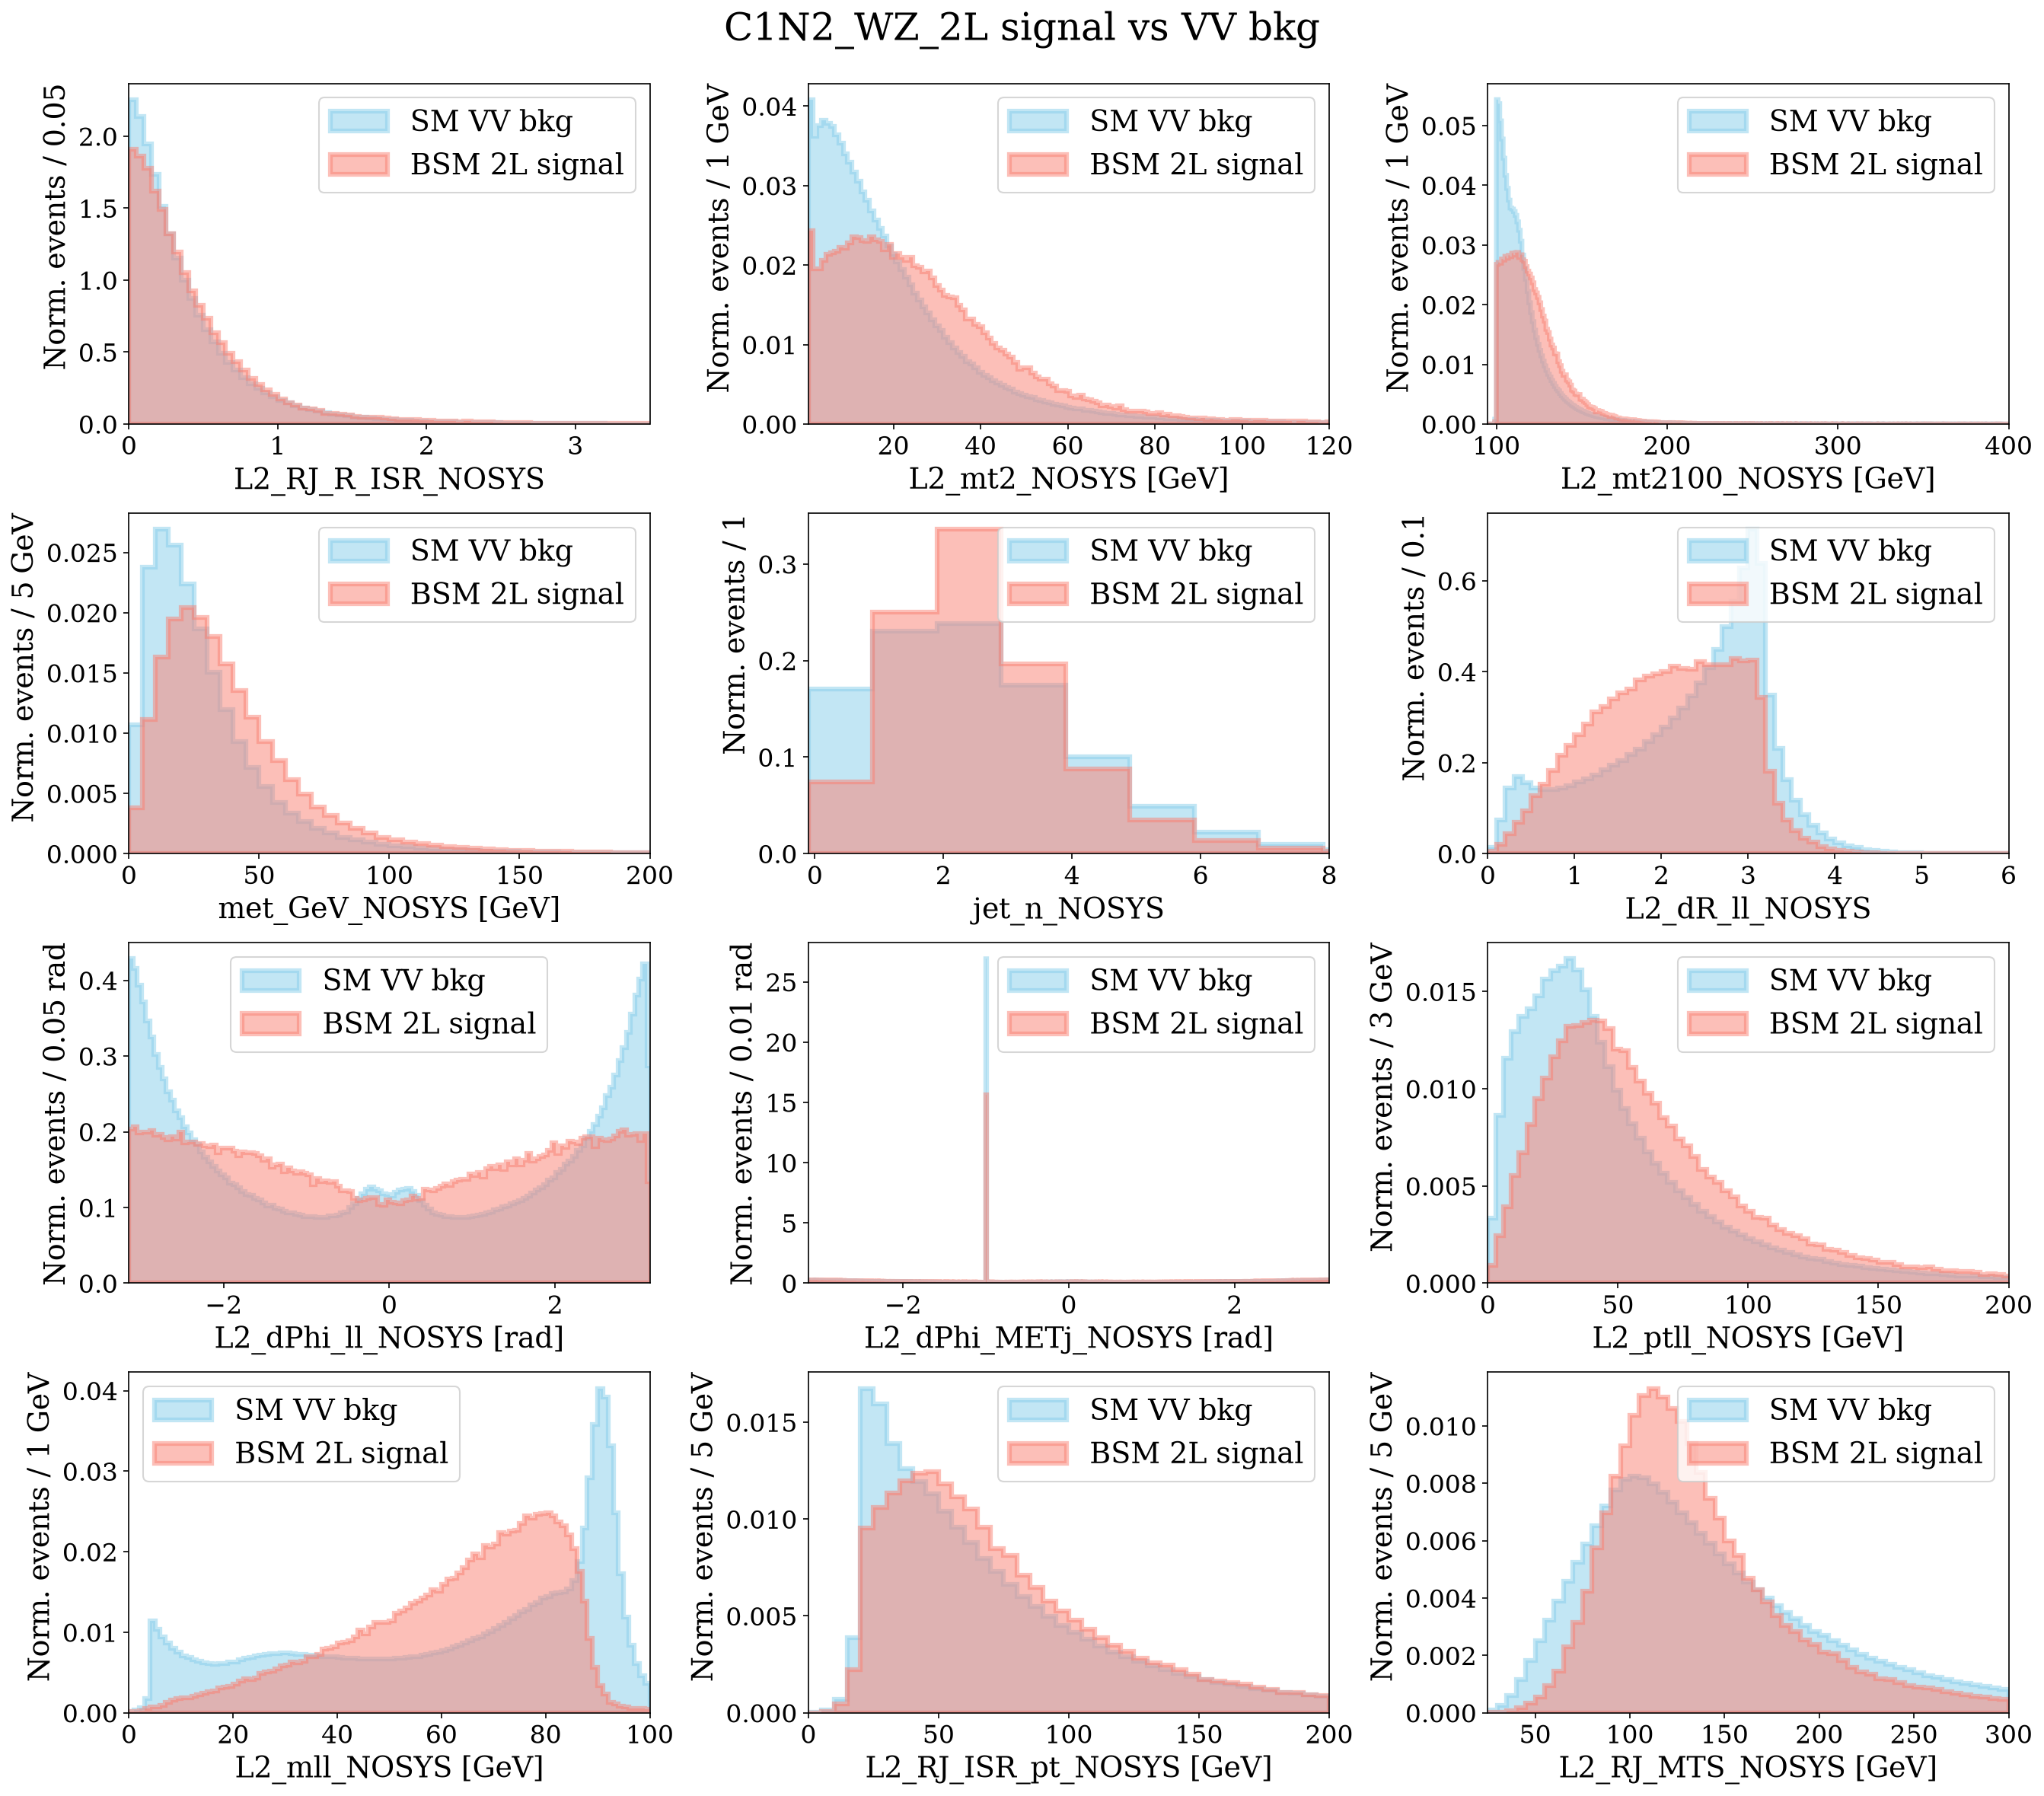

In [11]:
variables = [
    'L2_RJ_R_ISR_NOSYS', #Ratio between pt(invisible) and pt(ISR)
    'L2_mt2_NOSYS', #stransverse mass of the system assuming 2 invisible particles
    'L2_mt2100_NOSYS',
    'met_GeV_NOSYS', #missing transverse energy
    'jet_n_NOSYS', # number of jets
    'L2_dR_ll_NOSYS', # dR between the two leptons, were dR = \sqrt{(d\eta)^2 + (d\phi)^2}
    'L2_dPhi_ll_NOSYS', # dPhi between the two leptons
    'L2_dPhi_METj_NOSYS', # dPhi between the missing transverse energy and the leading jet
    'L2_ptll_NOSYS', # pt of the 2 lepton system
    'L2_mll_NOSYS',
    'L2_RJ_ISR_pt_NOSYS',
    'L2_RJ_MTS_NOSYS'
]

lin_log = {
    'L2_RJ_R_ISR_NOSYS':'lin',
    'L2_mt2_NOSYS':'lin',
    'L2_mt2100_NOSYS':'lin',
    'met_GeV_NOSYS': 'lin',
    'jet_n_NOSYS':'lin',
    'L2_dR_ll_NOSYS':'lin',
    'L2_dPhi_ll_NOSYS': 'lin',
    'L2_dPhi_METj_NOSYS':'lin',
    'L2_ptll_NOSYS': 'lin',
    'L2_mll_NOSYS':'lin',
    'L2_RJ_ISR_pt_NOSYS':'lin',
    'L2_RJ_MTS_NOSYS':'lin'
}

x_ranges = {
    'L2_RJ_R_ISR_NOSYS':(0,3.5),
    'L2_mt2_NOSYS': (0.5,120),
    'L2_mt2100_NOSYS': (95,400),
    'met_GeV_NOSYS': (0,200),
    'jet_n_NOSYS':(-0.1,8),
    'L2_dR_ll_NOSYS': (0,6),
    'L2_dPhi_ll_NOSYS': (-np.pi, np.pi),
    'L2_dPhi_METj_NOSYS':(-np.pi,np.pi),
    'L2_ptll_NOSYS': (0,200),
    'L2_mll_NOSYS': (0,100),
    'L2_RJ_ISR_pt_NOSYS':(0,200),
    'L2_RJ_MTS_NOSYS':(25,300)
}

wbins = {
    'L2_RJ_R_ISR_NOSYS': 0.05,
    'L2_mt2_NOSYS': 1,
    'L2_mt2100_NOSYS':1,
    'met_GeV_NOSYS': 5,
    'jet_n_NOSYS':1,
    'L2_dR_ll_NOSYS': 0.1,
    'L2_dPhi_ll_NOSYS': 0.05,
    'L2_dPhi_METj_NOSYS':0.01,
    'L2_ptll_NOSYS': 3,
    'L2_mll_NOSYS': 1,
    'L2_RJ_ISR_pt_NOSYS':5,
    'L2_RJ_MTS_NOSYS':5
}

units = {
    'L2_RJ_R_ISR_NOSYS': None,
    'L2_mt2_NOSYS': r'\mathrm{GeV}',
    'L2_mt2100_NOSYS':r'\mathrm{GeV}',
    'met_GeV_NOSYS': r'\mathrm{GeV}',
    'jet_n_NOSYS': None,
    'L2_dR_ll_NOSYS': None,
    'L2_dPhi_ll_NOSYS': r'\mathrm{rad}',
    'L2_dPhi_METj_NOSYS': r'\mathrm{rad}',
    'L2_ptll_NOSYS': r'\mathrm{GeV}',
    'L2_mll_NOSYS': r'\mathrm{GeV}',
    'L2_RJ_ISR_pt_NOSYS': r'\mathrm{GeV}',
    'L2_RJ_MTS_NOSYS': r'\mathrm{GeV}'
}

fig,axes = subplot_hist(df=df,variables=variables,title='C1N2_WZ_2L signal vs VV bkg',x_ranges=x_ranges,lin_log_dict=lin_log,
                       epsilon=10e-15,use_latex=False,wbins_dict=wbins,units_dict=units)

save_plot(USER='varom',directory='/nfs/pic.es/user/v/varom/SusyAD_IFAE/Plots',fig=fig,pdfname='10_07_26_A_FeaturePlots')

Consider weight_total_NOSYS for the plotting, weighted MC events.
Use ttbar_nonallhad and VV instead of VVV 
Use mc20a,d,e separately always, and stack sets and check
better log scale in y axis instead of normalising

weights only matter for stacking, if I plot 1 vs 1 doesn't matter

In [12]:
df['weight_total_NOSYS'].describe()

count    7.662271e+06
mean     5.789432e-03
std      2.283552e-02
min     -2.605570e-01
25%      5.209012e-04
50%      9.809171e-04
75%      5.199867e-03
max      1.321373e+00
Name: weight_total_NOSYS, dtype: float64